# 05 · The temporal drift experiment

This is the part that makes the project a piece of research rather than a homework exercise.

Notebook 04 used a *random* split, so the new fraud pattern from months 5–6 leaked into training. Real life doesn't work that way: you train on the past and deploy into the future. So here we:

1. Train every model on **months 1–4 only**.
2. Evaluate on **months 5–6**, which contain the injected new pattern.
3. Measure how much each model's AUC-PR **degrades** versus the friendly random split.
4. Zoom in on **recall for the drifted fraud specifically**.
5. **Retrain** the neural net on months 1–5 and test on month 6 — does it recover once it has seen a little of the new pattern?

Hypothesis: the expressive neural net overfits the *old* pattern and falls hardest under drift; gradient boosting degrades more gracefully; and a quick retrain rescues the net. If true, the real answer to "is the neural net better?" is **"it depends on your retraining cadence."**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fraud_utils as fu

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid")
ART = fu.ARTIFACTS_DIR
RNG = np.random.default_rng(42)
import models as M
import tensorflow as tf

I0000 00:00:1781285627.456974    1545 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1781285628.828108    1545 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
df = pd.read_parquet(os.path.join(ART, '02_features.parquet'))

feature_cols = ([c for c in df.columns if c.startswith('V')] +
                ['amount_log', 'amount_z', 'velocity_10m', 'velocity_1h',
                 'tod_sin', 'tod_cos', 'amount_bucket'])

def prep(train_months, test_months):
    from sklearn.preprocessing import StandardScaler
    tr, te = fu.temporal_split(df, train_months, test_months)
    sc = StandardScaler().fit(tr[feature_cols].values)
    Xtr = sc.transform(tr[feature_cols].values)
    Xte = sc.transform(te[feature_cols].values)
    return tr, te, Xtr, Xte, tr['Class'].values, te['Class'].values

tr, te, Xtr, Xte, ytr, yte = prep([1, 2, 3, 4], [5, 6])
print('train months 1-4:', Xtr.shape, 'fraud', int(ytr.sum()))
print('test  months 5-6:', Xte.shape, 'fraud', int(yte.sum()),
      '| drifted fraud:', int(te['is_drift'].sum()))

train months 1-4: (40117, 35) fraud 123
test  months 5-6: (20083, 35) fraud 77 | drifted fraud: 46


## Train everything on the past, score the future

Same model factories as notebook 03, so any difference is purely the train-on-past / test-on-future regime.

In [3]:
def train_all(Xtr, ytr, Xte):
    out = {}
    sk = M.get_sklearn_models(scale_pos_weight=M.pos_weight(ytr))
    for name, model in sk.items():
        model.fit(Xtr, ytr)
        out[name] = model.predict_proba(Xte)[:, 1]
    net = M.build_keras_mlp(Xtr.shape[1], l2=1e-3, dropout=0.3)
    net.fit(Xtr, ytr, epochs=30, batch_size=512,
            class_weight=M.class_weight_dict(ytr), verbose=0)
    out['nn_reg'] = net.predict(Xte, verbose=0).ravel()
    return out

drift_scores = train_all(Xtr, ytr, Xte)
print('trained:', list(drift_scores))

trained: ['logreg', 'tree', 'random_forest', 'xgboost', 'nn_reg']


## Degradation: random split vs temporal split

We line up each model's AUC-PR from notebook 04 (random, drift leaked into training) against its AUC-PR here (temporal, drift only in the future). The drop is the cost of distribution shift.

In [4]:
random_metrics = pd.read_parquet(os.path.join(ART, '04_metrics.parquet'))

comp = []
for m in drift_scores:
    temporal_ap = fu.evaluate_scores(yte, drift_scores[m])['auc_pr']
    random_ap = random_metrics.loc[m, 'auc_pr'] if m in random_metrics.index else np.nan
    comp.append({'model': m, 'random_split_ap': random_ap,
                 'temporal_ap': temporal_ap,
                 'drop': (random_ap - temporal_ap) if random_ap == random_ap else np.nan})
comp = pd.DataFrame(comp).set_index('model').sort_values('temporal_ap', ascending=False)
comp

,random_split_ap,temporal_ap,drop
model,,,
xgboost,0.9255,0.6710,0.2544
random_forest,0.8203,0.4517,0.3686
logreg,0.7177,0.4079,0.3098
nn_reg,0.8342,0.3959,0.4383
tree,0.3855,0.0847,0.3008


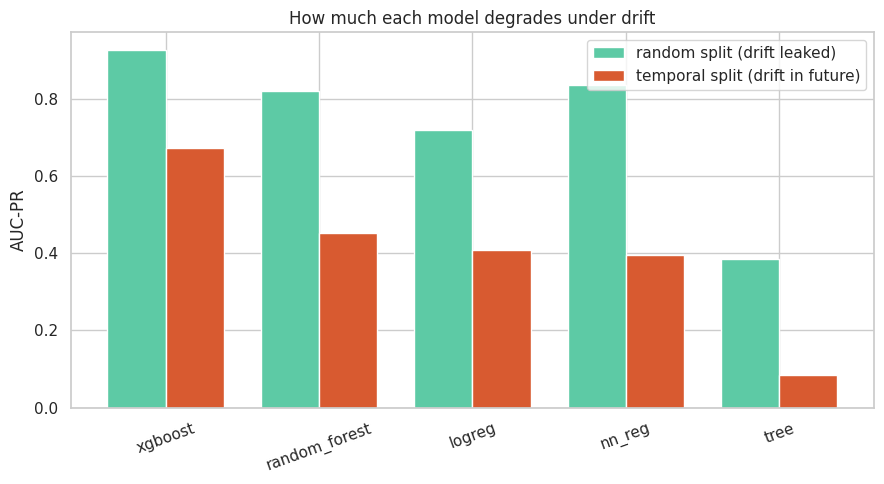

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
idx = np.arange(len(comp)); w = 0.38
ax.bar(idx - w/2, comp['random_split_ap'], w, label='random split (drift leaked)',
       color='#5DCAA5')
ax.bar(idx + w/2, comp['temporal_ap'], w, label='temporal split (drift in future)',
       color='#D85A30')
ax.set_xticks(idx); ax.set_xticklabels(comp.index, rotation=20)
ax.set_ylabel('AUC-PR'); ax.set_title('How much each model degrades under drift')
ax.legend(); plt.tight_layout(); plt.show()

## Where exactly does it fail? Recall on the drifted fraud

Overall AUC-PR hides the mechanism. Split the future fraud into **drifted** (the new pattern) and **normal**, and measure recall on each at a fixed operating threshold. The gap shows the models are blind to the *new* attack while still catching the old one.

In [6]:
thr = 0.5
is_drift_te = te['is_drift'].values
rows = []
for m, s in drift_scores.items():
    pred = (s >= thr).astype(int)
    fraud = yte == 1
    drift_mask = fraud & is_drift_te
    normal_mask = fraud & ~is_drift_te
    rows.append({
        'model': m,
        'recall_normal_fraud': pred[normal_mask].mean() if normal_mask.sum() else np.nan,
        'recall_drifted_fraud': pred[drift_mask].mean() if drift_mask.sum() else np.nan,
    })
recall_tbl = pd.DataFrame(rows).set_index('model')
recall_tbl

,recall_normal_fraud,recall_drifted_fraud
model,,
logreg,1.0000,0.0435
tree,0.8710,0.0217
random_forest,0.5484,0.0000
xgboost,0.9032,0.1522
nn_reg,0.9032,0.0435


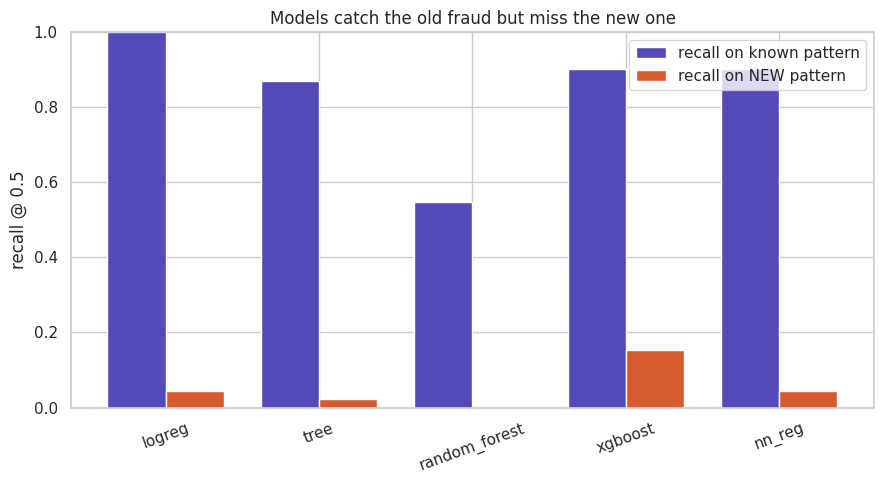

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
idx = np.arange(len(recall_tbl)); w = 0.38
ax.bar(idx - w/2, recall_tbl['recall_normal_fraud'], w,
       label='recall on known pattern', color='#534AB7')
ax.bar(idx + w/2, recall_tbl['recall_drifted_fraud'], w,
       label='recall on NEW pattern', color='#D85A30')
ax.set_xticks(idx); ax.set_xticklabels(recall_tbl.index, rotation=20)
ax.set_ylabel('recall @ 0.5'); ax.set_ylim(0, 1)
ax.set_title('Models catch the old fraud but miss the new one')
ax.legend(); plt.tight_layout(); plt.show()

## Recovery: give the net one more month

Retrain the neural net on months **1–5** (so it now sees *some* of the new pattern) and test on month **6**. Compare its drifted-fraud recall before and after. This is the quantitative version of "just retrain more often."

In [8]:
tr2, te2, Xtr2, Xte2, ytr2, yte2 = prep([1, 2, 3, 4, 5], [6])

net2 = M.build_keras_mlp(Xtr2.shape[1], l2=1e-3, dropout=0.3)
net2.fit(Xtr2, ytr2, epochs=30, batch_size=512,
         class_weight=M.class_weight_dict(ytr2), verbose=0)
s2 = net2.predict(Xte2, verbose=0).ravel()

drift6 = te2['is_drift'].values & (yte2 == 1)
before = None
# 'before' = the month-6 drifted recall from the model trained on 1-4
m6_mask = te['month'].values == 6
prev_pred = (drift_scores['nn_reg'][m6_mask] >= 0.5).astype(int)
prev_drift = drift6_prev = (te[te['month'] == 6]['is_drift'].values &
                            (yte[m6_mask] == 1))
before = prev_pred[prev_drift].mean() if prev_drift.sum() else float('nan')
after = (s2 >= 0.5).astype(int)[drift6].mean() if drift6.sum() else float('nan')
print(f'NN drifted-fraud recall on month 6')
print(f'  trained on months 1-4 (never saw new pattern): {before:.2%}')
print(f'  trained on months 1-5 (saw 1 month of it)    : {after:.2%}')

NN drifted-fraud recall on month 6
  trained on months 1-4 (never saw new pattern): 0.00%
  trained on months 1-5 (saw 1 month of it)    : 55.17%


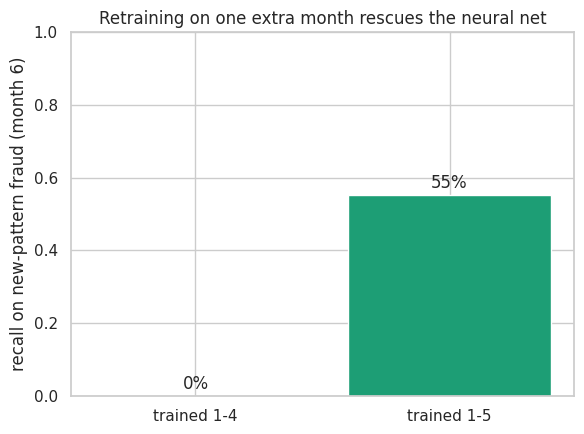

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(['trained 1-4', 'trained 1-5'], [before, after],
       color=['#D85A30', '#1D9E75'])
ax.set_ylim(0, 1); ax.set_ylabel('recall on new-pattern fraud (month 6)')
ax.set_title('Retraining on one extra month rescues the neural net')
for i, v in enumerate([before, after]):
    ax.text(i, v + 0.02, f'{v:.0%}', ha='center')
plt.tight_layout(); plt.show()

### Takeaways
- Under a realistic **train-past / test-future** regime, every model loses ground — the random-split ranking was optimistic.
- The damage is concentrated on the **new attack pattern**: models keep catching the fraud they were trained on and miss what changed.
- A single extra month of data restores the neural net's recall on the new pattern.

**So is the neural net "better"?** Not unconditionally. On static tabular data, boosting usually wins or ties. Under drift, raw model choice matters less than **how often you retrain**. That is the real production decision — and you now have the experiment to back it.